In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [66]:
df = pd.read_csv("C:/Users/hp/Downloads/titanic/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [67]:
df.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'], axis=1,inplace=True)
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [68]:
y = df['Survived']
X = df.drop('Survived', axis=1)

In [69]:
dummies = pd.get_dummies(X.Sex, dtype=int)
dummies.head()

,female,male
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1


In [70]:
X = pd.concat([X,dummies], axis=1)
X.drop('Sex', axis=1, inplace=True)
X.head(3)

,Pclass,Age,Fare,female,male
0,3,22.0,7.2500,0,1
1,1,38.0,71.2833,1,0
2,3,26.0,7.9250,1,0


In [71]:
X.isnull().sum()

Pclass      0
Age       177
Fare        0
female      0
male        0
dtype: int64

In [72]:
X['Age'] = X['Age'].fillna(X['Age'].mean())

In [73]:
print(X.isnull().sum().sum())

0


In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [75]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

In [76]:
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

In [77]:
nb.score(X_test, y_test)

0.776536312849162

In [78]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y_pred, y_test))
print(classification_report(y_pred, y_test))

[[86 21]
 [19 53]]
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       107
           1       0.72      0.74      0.73        72

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



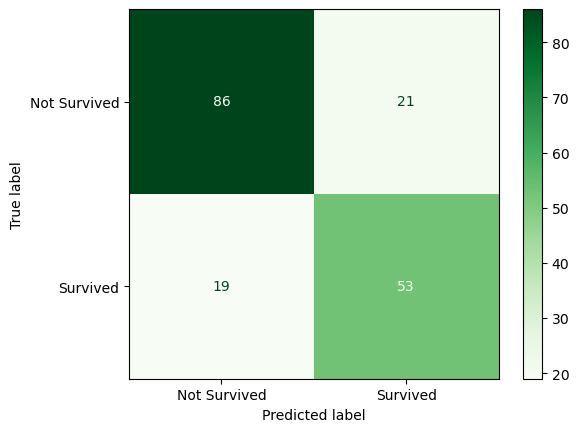

In [79]:
cm = confusion_matrix(y_pred, y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived','Survived'])
disp.plot(cmap='Greens')
plt.show()